In [2]:
from libs import *
from utilities import *

from Bio import SeqIO
import re
import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

import warnings
warnings.filterwarnings("ignore")


In [3]:
from Bio import SeqIO
import pandas as pd
import numpy as np

# Hydrophobicity scale (Kyte-Doolittle)
hydro_scale = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
    'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
    'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}

def extract_features(fasta_file):
    records = list(SeqIO.parse(fasta_file, "fasta"))
    features = []

    for record in records:
        seq = str(record.seq).upper()
        length = len(seq)

        # Amino acid composition
        counts = {aa: seq.count(aa) for aa in set(seq)}
        freq = {aa: counts.get(aa, 0) / length for aa in hydro_scale.keys()}

        # Hydrophobicity
        hydrophobicity = np.mean([hydro_scale.get(aa, 0) for aa in seq])

        # Cysteine count and pattern
        cysteine_count = seq.count('C')

        # Basic composition metrics
        gc_content = freq['G'] + freq['C']
        charge = freq['K'] + freq['R'] - freq['D'] - freq['E']
        aromaticity = freq['F'] + freq['Y'] + freq['W']

        # Motif checks (example: dibasic protease sites)
        has_dibasic_site = any(x in seq for x in ['KR', 'RR', 'RK'])

        features.append({
            'length': length,
            'hydrophobicity': hydrophobicity,
            'cysteine_count': cysteine_count,
            'gc_content': gc_content,
            'charge': charge,
            'aromaticity': aromaticity,
            'has_dibasic_site': int(has_dibasic_site),
            **freq
        })

    df = pd.DataFrame(features)
    return df

# Example usage
if __name__ == "__main__":
    df_new = extract_features("mango_data.fasta")
    df_new.to_csv("sspeptide_features.csv", index=False)


## Load data

In [6]:
df_new.head()

,length,hydrophobicity,cysteine_count,gc_content,charge,aromaticity,has_dibasic_site,A,R,N,...,L,K,M,F,P,S,T,W,Y,V
0,195,-0.830256,5,0.097436,0.076923,0.015385,1,0.066667,0.066667,0.025641,...,0.071795,0.138462,0.041026,0.015385,0.046154,0.087179,0.046154,0.000000,0.000000,0.061538
1,98,-0.502041,4,0.153061,-0.030612,0.091837,0,0.030612,0.061224,0.010204,...,0.061224,0.061224,0.020408,0.051020,0.030612,0.091837,0.030612,0.010204,0.030612,0.071429
2,196,-0.379082,5,0.142857,-0.025510,0.112245,1,0.030612,0.051020,0.035714,...,0.081633,0.056122,0.025510,0.061224,0.030612,0.086735,0.035714,0.010204,0.040816,0.056122
3,80,-1.118750,1,0.012500,-0.062500,0.075000,1,0.050000,0.062500,0.100000,...,0.087500,0.075000,0.037500,0.037500,0.012500,0.075000,0.012500,0.012500,0.025000,0.012500
4,177,-0.590395,3,0.045198,0.096045,0.084746,1,0.045198,0.039548,0.028249,...,0.084746,0.163842,0.050847,0.050847,0.045198,0.112994,0.050847,0.011299,0.022599,0.056497


In [41]:
result_signalp_mango = resultSignalP("../mango_signalp/prediction_results.txt")

In [7]:
df_new.columns.tolist()

['length',
 'hydrophobicity',
 'cysteine_count',
 'gc_content',
 'charge',
 'aromaticity',
 'has_dibasic_site',
 'A',
 'R',
 'N',
 'D',
 'C',
 'Q',
 'E',
 'G',
 'H',
 'I',
 'L',
 'K',
 'M',
 'F',
 'P',
 'S',
 'T',
 'W',
 'Y',
 'V']

In [8]:
numeric_cols = df_new.select_dtypes(include=[float, int]).columns.tolist()
scaler = StandardScaler()
df_standardized = df_new.copy()
df_standardized[numeric_cols] = scaler.fit_transform(df_new[numeric_cols])

print("✅ Normalization done!")
print(df_standardized.head())

✅ Normalization done!
     length  hydrophobicity  cysteine_count  gc_content    charge  \
0  1.443114       -1.225879        0.726159    0.364855  1.021051   
1 -0.966081       -0.479074        0.365935    1.858607 -0.771797   
2  1.467951       -0.199298        0.726159    1.584589 -0.686735   
3 -1.413148       -1.882303       -0.714737   -1.915997 -1.303436   
4  0.996047       -0.680111        0.005711   -1.037938  1.339858   

   aromaticity  has_dibasic_site         A         R         N  ...         L  \
0    -2.027132          0.608035 -0.066382  0.424907 -0.809853  ... -0.638750   
1     0.247046         -1.644642 -1.217304  0.231287 -1.546049  ... -0.949969   
2     0.854116          0.608035 -1.217304 -0.131750 -0.329453  ... -0.349100   
3    -0.253786          0.608035 -0.598412  0.276667  2.736369  ... -0.176350   
4     0.036115          0.608035 -0.751709 -0.539910 -0.685496  ... -0.257442   

          K         M         F         P         S         T         W  \
0

In [9]:
label_mango,sequence_mango = readFastaFiles("mango_data.fasta")


In [10]:
len(sequence_mango)

5046

In [42]:
# getting states
df = fasta_to_feature_vector("mango_data.fasta")

In [43]:
df.columns

Index(['sequence_id', 'length', 'amidation_candidate', 'num_cysteines',
       'disulfide_possible', 'num_glyco_sites', 'num_phospho_sites',
       'cysteine_density', 'glyco_density', 'phospho_density'],
      dtype='object')

In [44]:
df.shape

(5046, 10)

In [11]:
states = df_new.to_numpy().astype(np.float32)


In [12]:
states[0]

array([ 1.9500000e+02, -8.3025640e-01,  5.0000000e+00,  9.7435899e-02,
        7.6923080e-02,  1.5384615e-02,  1.0000000e+00,  6.6666670e-02,
        6.6666670e-02,  2.5641026e-02,  5.1282052e-02,  2.5641026e-02,
        5.1282052e-02,  7.6923080e-02,  7.1794875e-02,  2.0512821e-02,
        3.5897437e-02,  7.1794875e-02,  1.3846155e-01,  4.1025642e-02,
        1.5384615e-02,  4.6153847e-02,  8.7179489e-02,  4.6153847e-02,
        0.0000000e+00,  0.0000000e+00,  6.1538462e-02], dtype=float32)

In [235]:
states.shape

(5046, 27)

In [49]:
result_signalp_mango = resultSignalP("../mango_signalp/prediction_results.txt")

In [50]:
len(result_signalp_mango)

5046

In [51]:
unique, counts = np.unique(result_signalp_mango, return_counts=True)

In [13]:
#tape_data
mango_ebedding = np.load('sequence_mango.npy')

In [14]:
#ESM
embed2_mango = torch.load('embed2_mango.pt')

In [15]:
numpy_array_list = [tensor.numpy() for tensor in embed2_mango]
numpy_embed2_mango = np.array(numpy_array_list)

In [16]:
numpy_embed2_mango.shape

(5046, 1, 1280)

In [17]:
mango_ebedding2 = numpy_embed2_mango.reshape(numpy_embed2_mango.shape[0],numpy_embed2_mango.shape[2])


In [18]:
mango_ebedding2.shape

(5046, 1280)

In [19]:
len(embed2_mango)

5046

In [20]:
embedding_padded = np.concatenate((mango_ebedding, np.zeros((mango_ebedding.shape[0],16))), axis=1)
embedding2_padded = np.concatenate((mango_ebedding2, np.zeros((mango_ebedding2.shape[0],16))), axis=1)

In [21]:
shape_unit=28
embedding_images=np.reshape(embedding_padded,(embedding_padded.shape[0],shape_unit,shape_unit))

print(embedding_images.shape)

(5046, 28, 28)


In [22]:
shape_unit=36
embedding2_images=np.reshape(embedding2_padded,(embedding2_padded.shape[0],shape_unit,shape_unit))

print(embedding2_images.shape)

(5046, 36, 36)


In [23]:
#embedding_geotop = geotop_analysis(embedding_images)

In [24]:
#28*28
embedding_geotop = np.load("embedding_geotop_mango.npz")

In [25]:
#36*36
#embedding2_geotop = geotop_analysis(embedding2_images)

In [26]:
embedding2_geotop = np.load("embedding2_geotop_mango.npz")

In [27]:
embedding_geotop = [embedding_geotop['arr_'+str(i)] for i in range(len(embedding_geotop))]
embedding2_geotop = [embedding2_geotop['arr_'+str(i)] for i in range(len(embedding2_geotop))]

In [28]:
len(embedding2_geotop)

5046

# Trainning

### Tape and Geotop

In [29]:
dgms = gdr.DiagramSelector(use=True, point_type='finite').fit_transform(embedding_geotop)

In [30]:
dim = 1024
result = concate_embedding_geotop(mango_ebedding,dgms,dim)

In [31]:
#splitting the dataset
num_samples = len(result)
num_train_samples = int(0.8 * num_samples)  # 80% for training, 20% for testing

# Split data into training and testing sets
train_data, test_data = result[:num_train_samples], result[num_train_samples:]

In [32]:
shape_unit=32
std_scale = skp.StandardScaler().fit(train_data)
X_normalized = std_scale.transform(train_data)
train_data = np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [33]:
std_scale = skp.StandardScaler().fit(test_data)
X_normalized = std_scale.transform(test_data)
test_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [34]:
train_data_tape = np.expand_dims(train_data, -1)
test_data_tape = np.expand_dims(test_data, -1)

### ESM and Geotop

In [35]:
dgms = gdr.DiagramSelector(use=True, point_type='finite').fit_transform(embedding2_geotop)

In [36]:
dim = 1681
result = concate_embedding_geotop(mango_ebedding2,dgms,dim)

In [37]:
len(result)

5046

In [42]:
#splitting the dataset
#num_samples = len(result)
#num_train_samples = int(0.8 * num_samples)  # 80% for training, 20% for testing

# Split data into training and testing sets
train_data, test_data = result[:num_train_samples], result[num_train_samples:]
train_labels, test_labels = result_signalp_mango[:num_train_samples], result_signalp_mango[num_train_samples:]

In [43]:
shape_unit=41
std_scale = skp.StandardScaler().fit(train_data)
X_normalized = std_scale.transform(train_data)
train_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [44]:
std_scale = skp.StandardScaler().fit(test_data)
X_normalized = std_scale.transform(test_data)
test_data=np.reshape(X_normalized,(X_normalized.shape[0],shape_unit,shape_unit))

In [45]:
train_data_esm = np.expand_dims(train_data, -1)
test_data_esm = np.expand_dims(test_data, -1)

In [46]:
len(test_data_esm)

1010

In [48]:
unique, counts = np.unique(y_train, return_counts=True)
print(np.asarray((unique, counts)).T)

[[   0 3790]
 [   1  246]]


In [49]:
unique, counts = np.unique(y_test, return_counts=True)
print(np.asarray((unique, counts)).T)

[[  0 938]
 [  1  72]]


### Label

In [82]:
#train_labels, test_labels = result_signalp_mango[:num_train_samples], result_signalp_mango[num_train_samples:]

In [107]:
#y_train = np.array(train_labels)
#y_test = np.array(test_labels)

### state

In [236]:
len(states)

5046

In [237]:
states_train, states_test = states[:num_train_samples], states[num_train_samples:]

In [238]:
num_train_samples

4036

In [239]:
state_dim = 9

In [240]:
states_test.shape

(1010, 27)

## Reinforcement Learning

In [264]:
# Hyperparameters
n_pretrain_epochs = 50
batch_size_pretrain = 64
n_episodes = 200
gamma = 0.99
policy_lr = 1e-4
value_lr = 1e-4
clf_lr = 1e-4
ent_coef = 0.02        # Entropy coefficient for exploration
print_every = 10
eps = 1e-8

# Build classifier (CNN for ESM / TAPE)
def build_classifier(shape, model_name=None):
    model = Sequential(name=model_name)
    model.add(layers.Conv2D(8, (3,3), padding="same", activation='relu', input_shape=(shape[0], shape[1],1)))
    model.add(layers.AveragePooling2D())
    model.add(layers.Conv2D(16, (3,3), padding="same", activation='relu'))
    model.add(layers.AveragePooling2D())
    model.add(layers.Conv2D(32, (3,3), padding="same", activation='relu'))
    model.add(layers.AveragePooling2D())
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           bias_regularizer=regularizers.l2(1e-4),
                           activity_regularizer=regularizers.l2(1e-5)))
    model.add(layers.Dense(64, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4),
                           bias_regularizer=regularizers.l2(1e-4),
                           activity_regularizer=regularizers.l2(1e-5)))
    model.add(layers.Dense(1))  # logits output (no sigmoid)
    return model


# Policy Network
class PolicyNetwork(tf.keras.Model):
    def __init__(self, state_dim, hidden=(128, 64), dropout_rate=0.1):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.h1 = layers.Dense(hidden[0], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do1 = layers.Dropout(dropout_rate)
        self.h2 = layers.Dense(hidden[1], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do2 = layers.Dropout(dropout_rate)
        self.logit = layers.Dense(1, activation=None, kernel_initializer="glorot_uniform")

    def call(self, x, training=False):
        x = self.norm(x)
        x = self.h1(x); x = self.do1(x, training=training)
        x = self.h2(x); x = self.do2(x, training=training)
        return self.logit(x)

    @tf.function
    def sample(self, x, training=False, eps=1e-8):
        logit = self(x, training=training)
        p = tf.sigmoid(tf.clip_by_value(logit, -5.0, 5.0))
        u = tf.random.uniform(tf.shape(p))
        action = tf.cast(u < p, tf.float32)
        logp = action * tf.math.log(p + eps) + (1.0 - action) * tf.math.log(1.0 - p + eps)
        entropy = -(p * tf.math.log(p + eps) + (1.0 - p) * tf.math.log(1.0 - p + eps))
        return action, tf.reshape(logp, (-1,)), tf.reshape(entropy, (-1,)), p


# Value Network
class ValueNetwork(tf.keras.Model):
    def __init__(self, state_dim, hidden=(128, 64), dropout_rate=0.1):
        super().__init__()
        self.norm = layers.LayerNormalization()
        self.h1 = layers.Dense(hidden[0], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do1 = layers.Dropout(dropout_rate)
        self.h2 = layers.Dense(hidden[1], activation=tf.nn.gelu, kernel_initializer="he_normal")
        self.do2 = layers.Dropout(dropout_rate)
        self.v_out = layers.Dense(1, activation=None, kernel_initializer="glorot_uniform")

    def call(self, x, training=False):
        x = self.norm(x)
        x = self.h1(x); x = self.do1(x, training=training)
        x = self.h2(x); x = self.do2(x, training=training)
        return self.v_out(x)


#  Losses and Optimizers
loss_fn = losses.BinaryCrossentropy(from_logits=True, reduction=losses.Reduction.NONE)
clf_optimizer = optimizers.Adam(clf_lr)
policy_optimizer = optimizers.Adam(policy_lr, clipnorm=1.0)
value_optimizer = optimizers.Adam(value_lr, clipnorm=1.0)
value_loss_fn = tf.keras.losses.MeanSquaredError()

#  Build models
dim_ESM = train_data_esm.shape[1:3]
dim_TAPE = train_data_tape.shape[1:3]
classifier_ESM = build_classifier(dim_ESM, "classifier_ESM")
classifier_TAPE = build_classifier(dim_TAPE, "classifier_TAPE")
state_dim = states_train.shape[1]
policy = PolicyNetwork(state_dim)
value_net = ValueNetwork(state_dim)

#  Labels reshaping
if y_train.ndim == 1:
    y_train = y_train.reshape(-1, 1)

# 🧪 Pretrain classifiers

def pretrain_classifier(model, X, y, epochs=5, batch_size=64):
    dataset = tf.data.Dataset.from_tensor_slices((X, y)).shuffle(1000).batch(batch_size)
    opt = optimizers.Adam(clf_lr)
    for epoch in range(epochs):
        epoch_losses = []
        for Xb, yb in dataset:
            if yb.ndim == 1:
                yb = tf.reshape(yb, (-1,1))
            with tf.GradientTape() as t:
                logits = model(Xb, training=True)
                loss_vals = loss_fn(yb, logits)
                loss = tf.reduce_mean(loss_vals)
            grads = t.gradient(loss, model.trainable_variables)
            opt.apply_gradients(zip(grads, model.trainable_variables))
            epoch_losses.append(loss.numpy())
        print(f"[Pretrain] {model.name} epoch {epoch+1}/{epochs} loss={np.mean(epoch_losses):.4f}")

print("=> Pretraining classifiers...")
pretrain_classifier(classifier_ESM, train_data_esm, y_train, epochs=n_pretrain_epochs, batch_size=batch_size_pretrain)
pretrain_classifier(classifier_TAPE, train_data_tape, y_train, epochs=n_pretrain_epochs, batch_size=batch_size_pretrain)

classifier_ESM.trainable = False
classifier_TAPE.trainable = False

# Evaluation function
def eval_classifier(model, X, y):
    if y.ndim == 1:
        y = y.reshape(-1,1)
    logits = model(X, training=False)
    preds = tf.sigmoid(logits) > 0.5
    acc = np.mean((preds.numpy().astype(np.float32) == y.astype(np.float32)))
    avg_loss = np.mean(loss_fn(y, logits).numpy())
    return acc, avg_loss

hold_idx = np.random.choice(len(states_train), size=min(500, len(states_train)), replace=False)
y_hold = y_train[hold_idx]
acc_esm, loss_esm = eval_classifier(classifier_ESM, train_data_esm[hold_idx], y_hold)
acc_tape, loss_tape = eval_classifier(classifier_TAPE, train_data_tape[hold_idx], y_hold)
print(f"[Eval holdout] ESM acc={acc_esm:.4f} loss={loss_esm:.4f} | TAPE acc={acc_tape:.4f} loss={loss_tape:.4f}")

# Actor–Critic RL loop
N = len(states_train)

for episode in range(1, n_episodes+1):
    idx = np.random.permutation(N)

    log_probs_list, rewards_list, chosen_idxs, true_labels, preds_for_acc = [], [], [], [], []

    for i in idx:
        state_sample = tf.convert_to_tensor(states_train[i:i+1], dtype=tf.float32)
        action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
        log_probs_list.append(logp)

        if int(action.numpy().flatten()[0]) == 0:
            classifier = classifier_ESM
            X_sample = train_data_esm[i:i+1]
        else:
            classifier = classifier_TAPE
            X_sample = train_data_tape[i:i+1]

        y_sample = y_train[i:i+1]
        if y_sample.ndim == 1:
            y_sample = y_sample.reshape(-1,1)

        logits_clf = classifier(tf.convert_to_tensor(X_sample, dtype=tf.float32), training=False)
        loss_scalar = tf.reduce_mean(loss_fn(y_sample, logits_clf))
        pred = tf.cast(tf.sigmoid(logits_clf) > 0.5, tf.float32)

        is_correct = 1.0 if (pred.numpy().flatten()[0] == y_sample.flatten()[0]) else 0.0
        reward = -loss_scalar + 1.0 * is_correct # the policy picks the classifier that performs better on this sample
        rewards_list.append(tf.reshape(reward, (-1,)))
        preds_for_acc.append(pred.numpy().flatten()[0])
        chosen_idxs.append(int(action.numpy().flatten()[0]))
        true_labels.append(y_sample.flatten()[0])

    # --- Discounted rewards ---
    rewards_np = np.array([r.numpy()[0] for r in rewards_list])
    discounted = []
    R = 0.0
    for r in reversed(rewards_np):
        R = r + gamma * R
        discounted.insert(0, R)
    discounted = tf.convert_to_tensor(discounted, dtype=tf.float32)
    discounted = (discounted - tf.reduce_mean(discounted)) / (tf.math.reduce_std(discounted) + 1e-8)

    # --- Prepare tensors ---
    states_batch = tf.convert_to_tensor(states_train[idx], dtype=tf.float32)
    actions_taken = tf.reshape(tf.convert_to_tensor(chosen_idxs, dtype=tf.float32), (-1,1))

    # ===== Value Update =====
    with tf.GradientTape() as tape_v:
        values = tf.squeeze(value_net(states_batch, training=True), axis=-1)
        v_loss = value_loss_fn(discounted, values)
    v_grads = tape_v.gradient(v_loss, value_net.trainable_variables)
    value_optimizer.apply_gradients(zip(v_grads, value_net.trainable_variables))

    # ===== Policy Update =====
    with tf.GradientTape() as tape_pg:
        logits_batch = policy(states_batch, training=True)
        probs_batch = tf.sigmoid(tf.clip_by_value(logits_batch, -5.0, 5.0))
        logp_batch = actions_taken * tf.math.log(probs_batch + eps) + (1.0 - actions_taken) * tf.math.log(1.0 - probs_batch + eps)
        logp_batch = tf.reshape(logp_batch, (-1,))

        values = tf.squeeze(value_net(states_batch, training=False), axis=-1)
        advantages = discounted - tf.stop_gradient(values)
        advantages = (advantages - tf.reduce_mean(advantages)) / (tf.math.reduce_std(advantages) + 1e-8)

        entropy_batch = -(probs_batch * tf.math.log(probs_batch + eps)
                          + (1.0 - probs_batch) * tf.math.log(1.0 - probs_batch + eps))
        entropy_batch = tf.reshape(entropy_batch, (-1,))

        pg_loss = -tf.reduce_mean(logp_batch * advantages) - ent_coef * tf.reduce_mean(entropy_batch)

    pg_grads = tape_pg.gradient(pg_loss, policy.trainable_variables)
    policy_optimizer.apply_gradients(zip(pg_grads, policy.trainable_variables))

    # --- Logging ---
    avg_reward = np.mean(rewards_np)
    policy_loss_val = pg_loss.numpy()
    overall_acc = np.mean(np.array(preds_for_acc) == np.array(true_labels))
    mean_prob = tf.reduce_mean(tf.sigmoid(policy(tf.convert_to_tensor(states_train, dtype=tf.float32)))).numpy()

    if episode % print_every == 0 or episode == 1:
        acc_esm_hold, loss_esm_hold = eval_classifier(classifier_ESM, train_data_esm[hold_idx], y_hold)
        acc_tape_hold, loss_tape_hold = eval_classifier(classifier_TAPE, train_data_tape[hold_idx], y_hold)
        print(f"Episode {episode}/{n_episodes} | avg_reward={avg_reward:.4f} | policy_loss={policy_loss_val:.6f} | "
              f"value_loss={v_loss.numpy():.6f} | overall_acc={overall_acc:.4f} | mean_policy_prob={mean_prob:.3f}")
        print(f"  holdout ESM acc={acc_esm_hold:.4f} loss={loss_esm_hold:.4f} | TAPE acc={acc_tape_hold:.4f} loss={loss_tape_hold:.4f}")


=> Pretraining classifiers...
[Pretrain] classifier_ESM epoch 1/50 loss=0.4089
[Pretrain] classifier_ESM epoch 2/50 loss=0.2325
[Pretrain] classifier_ESM epoch 3/50 loss=0.2321
[Pretrain] classifier_ESM epoch 4/50 loss=0.2424
[Pretrain] classifier_ESM epoch 5/50 loss=0.2284
[Pretrain] classifier_ESM epoch 6/50 loss=0.2267
[Pretrain] classifier_ESM epoch 7/50 loss=0.2237
[Pretrain] classifier_ESM epoch 8/50 loss=0.2186
[Pretrain] classifier_ESM epoch 9/50 loss=0.2211
[Pretrain] classifier_ESM epoch 10/50 loss=0.2040
[Pretrain] classifier_ESM epoch 11/50 loss=0.1937
[Pretrain] classifier_ESM epoch 12/50 loss=0.1751
[Pretrain] classifier_ESM epoch 13/50 loss=0.1661
[Pretrain] classifier_ESM epoch 14/50 loss=0.1470
[Pretrain] classifier_ESM epoch 15/50 loss=0.1361
[Pretrain] classifier_ESM epoch 16/50 loss=0.1280
[Pretrain] classifier_ESM epoch 17/50 loss=0.1215
[Pretrain] classifier_ESM epoch 18/50 loss=0.1190
[Pretrain] classifier_ESM epoch 19/50 loss=0.1172
[Pretrain] classifier_ESM epo

In [265]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---- Evaluate ESM Classifier ----
y_pred_esm = classifier_ESM.predict(test_data_esm)
y_pred_esm_binary = (y_pred_esm > 0.5).astype(int)

print("\n ESM Classifier Performance:")
print("Accuracy:", accuracy_score(test_labels, y_pred_esm_binary))
print("Precision:", precision_score(test_labels, y_pred_esm_binary))
print("Recall:", recall_score(test_labels, y_pred_esm_binary))
print("F1 Score:", f1_score(test_labels, y_pred_esm_binary))
print("ROC-AUC:", roc_auc_score(test_labels, y_pred_esm))

# ---- Evaluate TAPE Classifier ----
y_pred_tape = classifier_TAPE.predict(test_data_tape)
y_pred_tape_binary = (y_pred_tape > 0.5).astype(int)

print("\n TAPE Classifier Performance:")
print("Accuracy:", accuracy_score(test_labels, y_pred_tape_binary))
print("Precision:", precision_score(test_labels, y_pred_tape_binary))
print("Recall:", recall_score(test_labels, y_pred_tape_binary))
print("F1 Score:", f1_score(test_labels, y_pred_tape_binary))
print("ROC-AUC:", roc_auc_score(test_labels, y_pred_tape))


32/32 [==============================] - 1s 11ms/step

📊 ESM Classifier Performance:
Accuracy: 0.9584158415841584
Precision: 0.8125
Recall: 0.5416666666666666
F1 Score: 0.65
ROC-AUC: 0.9303038379530917
32/32 [==============================] - 0s 5ms/step

📊 TAPE Classifier Performance:
Accuracy: 0.9643564356435643
Precision: 0.8214285714285714
Recall: 0.6388888888888888
F1 Score: 0.7187499999999999
ROC-AUC: 0.9405798389007345


In [266]:
esm_count, tape_count = 0, 0

for i in range(len(states_test)):
    state_sample = tf.convert_to_tensor(states_test[i:i+1], dtype=tf.float32)
    action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
    log_probs_list.append(logp)

    if int(action.numpy().flatten()[0]) == 0:
        esm_count += 1
    else:
        tape_count += 1


print("\n Policy Selection Summary:")
print(f"Chose ESM:  {esm_count} samples ({esm_count/len(states_test)*100:.1f}%)")
print(f"Chose TAPE: {tape_count} samples ({tape_count/len(states_test)*100:.1f}%)")


📈 Policy Selection Summary:
Chose ESM:  491 samples (48.6%)
Chose TAPE: 519 samples (51.4%)


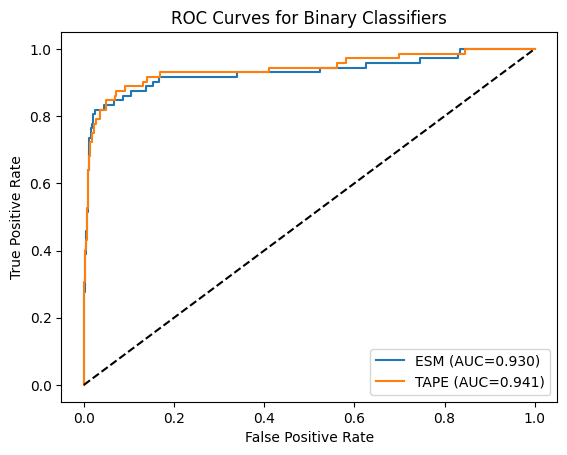

In [267]:
fpr_esm, tpr_esm, _ = roc_curve(test_labels, y_pred_esm)
fpr_tape, tpr_tape, _ = roc_curve(test_labels, y_pred_tape)

plt.plot(fpr_esm, tpr_esm, label='ESM (AUC=%.3f)' % roc_auc_score(test_labels, y_pred_esm))
plt.plot(fpr_tape, tpr_tape, label='TAPE (AUC=%.3f)' % roc_auc_score(test_labels, y_pred_tape))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curves for Binary Classifiers')
plt.show()


In [268]:
correct = 0
pred_rl = []
for i in range(len(states_test)):
    state_sample = tf.convert_to_tensor(states_test[i:i+1], dtype=tf.float32)
    action, logp, entropy, prob = policy.sample(state_sample, training=True, eps=eps)
    log_probs_list.append(logp)

    if int(action.numpy().flatten()[0]) == 0:
        classifier = classifier_ESM
        X_sample = test_data_esm[i:i+1]
    else:
        classifier = classifier_TAPE
        X_sample = test_data_tape[i:i+1]

    y_sample = y_test[i:i+1]
    if y_sample.ndim == 1:
        y_sample = y_sample.reshape(-1,1)

    logits_clf = classifier(tf.convert_to_tensor(X_sample, dtype=tf.float32), training=False)
    loss_scalar = tf.reduce_mean(loss_fn(y_sample, logits_clf))
    pred = tf.cast(tf.sigmoid(logits_clf) > 0.5, tf.float32)
    pred_rl.append(pred.numpy().flatten()[0])
    
    # Count correct predictions
    #is_correct = 1.0 if (pred.numpy().flatten()[0] == y_sample.flatten()[0]) else 0.0
    if pred.numpy().flatten()[0] == y_test[i]:
        correct += 1

accuracy = correct / len(states_test)
print("\n✅ Test accuracy with learned policy:", accuracy)



✅ Test accuracy with learned policy: 0.9702970297029703


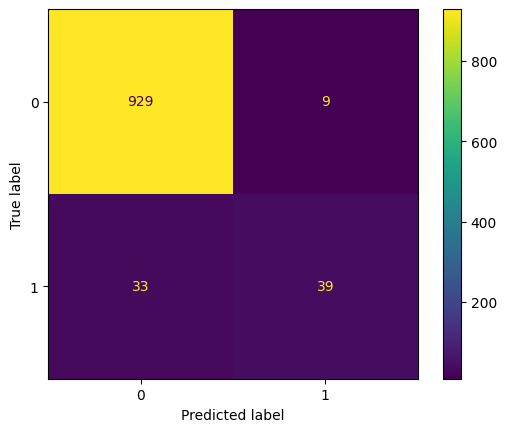

In [269]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_labels, y_pred_esm_binary)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

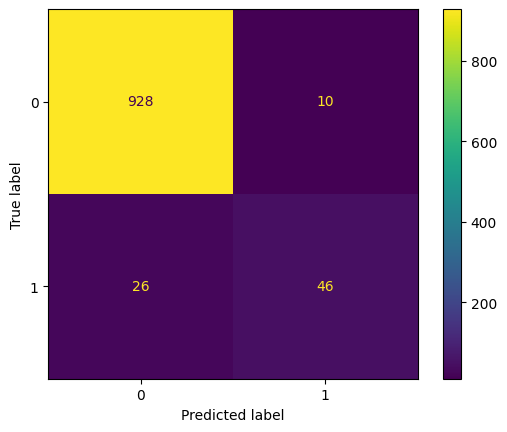

In [270]:
cm = confusion_matrix(test_labels, y_pred_tape_binary)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.show()

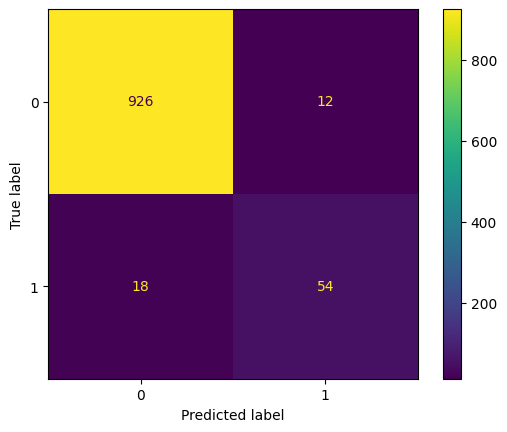

In [271]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_labels, pred_rl)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[0, 1])
cm_display.plot()
plt.show()